In [1]:
%pip install openai-whisper yt-dlp moviepy transformers datasets accelerate evaluate seqeval
!pip install thefuzz python-Levenshtein

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 55.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 18.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.3 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=1644de892188878ea0e7bafa5d61e1a6fa28fe97cfdabe1bd3d6136cb7b79b9d
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=d2f856489ca5680d8cdcdf4ed49fd9829aa60df479573ccdd859c1350e99b

## Event Model Training

In [2]:
# ==============================================================================
#  EVENT MODEL TRAINING
# ==============================================================================

import json
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("\n" + "="*40)
print("🚀 1. PREPARING EVENT MODEL...")
print("="*40)

# --- 1. LOADING THE DATASET ---
# Note: If your dataset has a different name, change it below.
data_file = "/content/football_dataset.json"
print(f"📂 Loading dataset: {data_file}")

with open(data_file, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Parse data (Based on Event label)
texts = [item["text"] for item in raw_data]
labels = [item["event_label"] for item in raw_data] # Pay attention to key name in JSON

# Find unique labels
unique_labels = sorted(list(set(labels)))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for i, label in enumerate(unique_labels)}

print(f"✅ Detected classes ({len(unique_labels)} count): {unique_labels}")

# Convert to Dataset object
hf_dataset = Dataset.from_dict({"text": texts, "label": [label2id[l] for l in labels]})
dataset_split = hf_dataset.train_test_split(test_size=0.2)

# --- 2. TOKENIZER AND MODEL ---
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

print("⚙️ Tokenizing data...")
tokenized_datasets = dataset_split.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)

# Device check (Use GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# --- 3. TRAINING ---
training_args = TrainingArguments(
    output_dir="./results_event",
    num_train_epochs=3,              # Adjust epoch count as needed
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",              # Disk saving disabled (Keeping in RAM)
    logging_dir='./logs_event',
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("🏋️‍♂️ Training starting...")
trainer.train()


🚀 1. PREPARING EVENT MODEL...
📂 Loading dataset: /content/football_dataset.json
✅ Detected classes (6 count): ['CARD', 'FOUL_OFFSIDE', 'GOAL', 'INJURY', 'NONE', 'SUBSTITUTION']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️‍♂️ Training starting...


Epoch,Training Loss,Validation Loss
1,No log,0.933510
2,No log,0.424990
3,No log,0.322951


TrainOutput(global_step=195, training_loss=0.8121754964192708, metrics={'train_runtime': 64.5826, 'train_samples_per_second': 48.31, 'train_steps_per_second': 3.019, 'total_flos': 413327766159360.0, 'train_loss': 0.8121754964192708, 'epoch': 3.0})

### Event Model Performance


📊 Evaluating Model on Test Set...



📝 Classification Report:
              precision    recall  f1-score   support

        CARD       1.00      1.00      1.00        38
FOUL_OFFSIDE       1.00      0.96      0.98        51
        GOAL       0.84      1.00      0.91        53
      INJURY       1.00      1.00      1.00        40
        NONE       1.00      0.79      0.88        42
SUBSTITUTION       0.97      1.00      0.99        36

    accuracy                           0.96       260
   macro avg       0.97      0.96      0.96       260
weighted avg       0.96      0.96      0.96       260



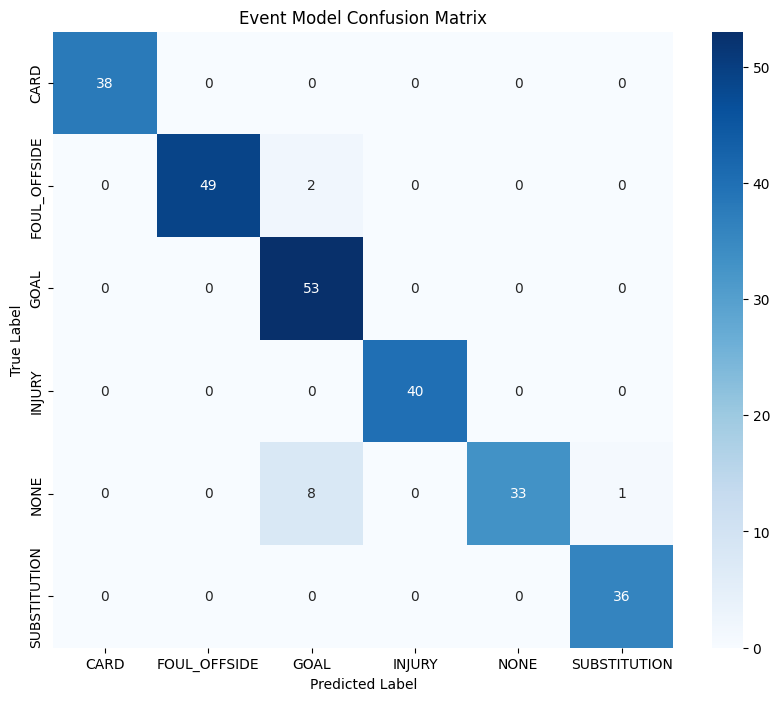

In [3]:

# --- 4. PERFORMANCE ANALYSIS (VISUALIZATION) ---
print("\n📊 Evaluating Model on Test Set...")
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\n📝 Classification Report:")
print(classification_report(true_labels, preds, target_names=unique_labels))

# Plotting Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Event Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Save the Model

In [4]:

# --- 5. SAVING MODEL TO MEMORY AND CLEANUP (CRITICAL PART) ---
print("💾 Transferring model to global variables...")

# Assign Model and Tokenizer to global variables (To be used in Pipeline)
event_model = model
event_tokenizer = tokenizer

print("🧹 Cleaning RAM and GPU...")

# 1. Delete heavy variables related to training
del model
del trainer
del hf_dataset
del dataset_split
del tokenized_datasets
del predictions

# 2. Run Python garbage collector (Clean RAM)
gc.collect()

# 3. Empty GPU cache (Clean VRAM)
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ EVENT MODEL READY. (RAM cleaned, model stored in 'event_model' variable)")

💾 Transferring model to global variables...
🧹 Cleaning RAM and GPU...
✅ EVENT MODEL READY. (RAM cleaned, model stored in 'event_model' variable)


## NER Model Training

In [5]:
# ==============================================================================
# 🚀 CELL 3: NER (NAMED ENTITY RECOGNITION) MODEL TRAINING
# ==============================================================================

import json
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
from sklearn.metrics import confusion_matrix, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)

print("\n" + "="*40)
print("🚀 2. PREPARING NER (PLAYER/TEAM DETECTION) MODEL...")
print("="*40)

# --- 1. LOADING DATASET AND TRANSFORMATION ---
data_file = "/content/football_dataset.json"
print(f"📂 Loading dataset: {data_file}")

with open(data_file, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# NER Label List (Based on your dataset structure)
# Labels: PLAYER, TEAM, COACH, STADIUM
ner_labels = [
    'O',
    'B-PLAYER', 'I-PLAYER',
    'B-TEAM', 'I-TEAM',
    'B-COACH', 'I-COACH',
    'B-STADIUM', 'I-STADIUM'
]

id2label = {i: label for i, label in enumerate(ner_labels)}
label2id = {label: i for i, label in enumerate(ner_labels)}
print(f"✅ Target NER Labels: {ner_labels}")

# --- TOKENIZER ---
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# --- 2. DATA ALIGNMENT FUNCTION (CRITICAL FOR YOUR DATASET) ---
# Converts "start/end" character offsets to "B-PLAYER, I-PLAYER" token tags.
def align_labels_with_tokens(examples):
    tokenized_inputs = tokenizer(examples["text"], truncation=True, is_split_into_words=False)

    all_labels = []

    for i, text in enumerate(examples["text"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        tags = examples["ner_tags"][i] # Tag list from JSON

        labels = []
        # Assign label for each token
        for token_index, word_idx in enumerate(word_ids):
            if word_idx is None:
                labels.append(-100) # Special tokens ([CLS], [SEP])
            else:
                # Find character span of this token
                token_span = tokenized_inputs.token_to_chars(i, token_index)
                if not token_span:
                    labels.append(0) # 'O'
                    continue

                token_start, token_end = token_span.start, token_span.end

                # Is this token inside any entity?
                match_label = 0 # Default 'O'

                for tag in tags:
                    entity_start = tag["start"]
                    entity_end = tag["end"]
                    entity_label = tag["label"] # e.g., PLAYER

                    # If token is within the entity range
                    if token_start >= entity_start and token_end <= entity_end:
                        # Beginning (B-) or Inside (I-)?
                        prefix = "B-" if token_start == entity_start else "I-"
                        full_label = prefix + entity_label

                        if full_label in label2id:
                            match_label = label2id[full_label]
                        break

                labels.append(match_label)

        all_labels.append(labels)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

print("⚙️ Processing and aligning data (Character offsets -> Token IDs)...")

# Convert to HuggingFace Dataset
hf_dataset = Dataset.from_list(raw_data)
# Apply transformation
tokenized_datasets = hf_dataset.map(align_labels_with_tokens, batched=True, remove_columns=hf_dataset.column_names)

# Split Train/Test
dataset_split = tokenized_datasets.train_test_split(test_size=0.2)

# Data Collator
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# --- 3. METRICS ---
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [ner_labels[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [ner_labels[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# --- 4. MODEL AND TRAINING ---
model = AutoModelForTokenClassification.from_pretrained(
    model_ckpt, num_labels=len(ner_labels), id2label=id2label, label2id=label2id
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

training_args = TrainingArguments(
    output_dir="./results_ner",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="no",
    logging_dir='./logs_ner',
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_split["train"],
    eval_dataset=dataset_split["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


trainer.train()



🚀 2. PREPARING NER (PLAYER/TEAM DETECTION) MODEL...
📂 Loading dataset: /content/football_dataset.json
✅ Target NER Labels: ['O', 'B-PLAYER', 'I-PLAYER', 'B-TEAM', 'I-TEAM', 'B-COACH', 'I-COACH', 'B-STADIUM', 'I-STADIUM']
⚙️ Processing and aligning data (Character offsets -> Token IDs)...


Map:   0%|          | 0/1300 [00:00<?, ? examples/s]

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-554934799.py:159: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.232603,0.590062,0.572289,0.581040,0.930821
2,No log,0.158476,0.674923,0.656627,0.665649,0.948963
3,No log,0.146346,0.693498,0.674699,0.683969,0.951156


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TrainOutput(global_step=195, training_loss=0.2970409882374299, metrics={'train_runtime': 6.9527, 'train_samples_per_second': 448.748, 'train_steps_per_second': 28.047, 'total_flos': 23463366623424.0, 'train_loss': 0.2970409882374299, 'epoch': 3.0})

### NER Model Performance


📊 Evaluating Model on Test Set...



📝 Classification Report:
              precision    recall  f1-score   support

     B-COACH       1.00      0.30      0.47        23
    B-PLAYER       0.81      0.85      0.83       208
   B-STADIUM       0.00      0.00      0.00         6
      B-TEAM       0.67      0.87      0.75        23
     I-COACH       0.80      0.80      0.80        59
    I-PLAYER       0.84      0.88      0.86       596
   I-STADIUM       0.00      0.00      0.00         7
      I-TEAM       1.00      0.21      0.35        19
           O       0.98      0.98      0.98      4075

    accuracy                           0.95      5016
   macro avg       0.68      0.54      0.56      5016
weighted avg       0.95      0.95      0.95      5016

📉 Plotting Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


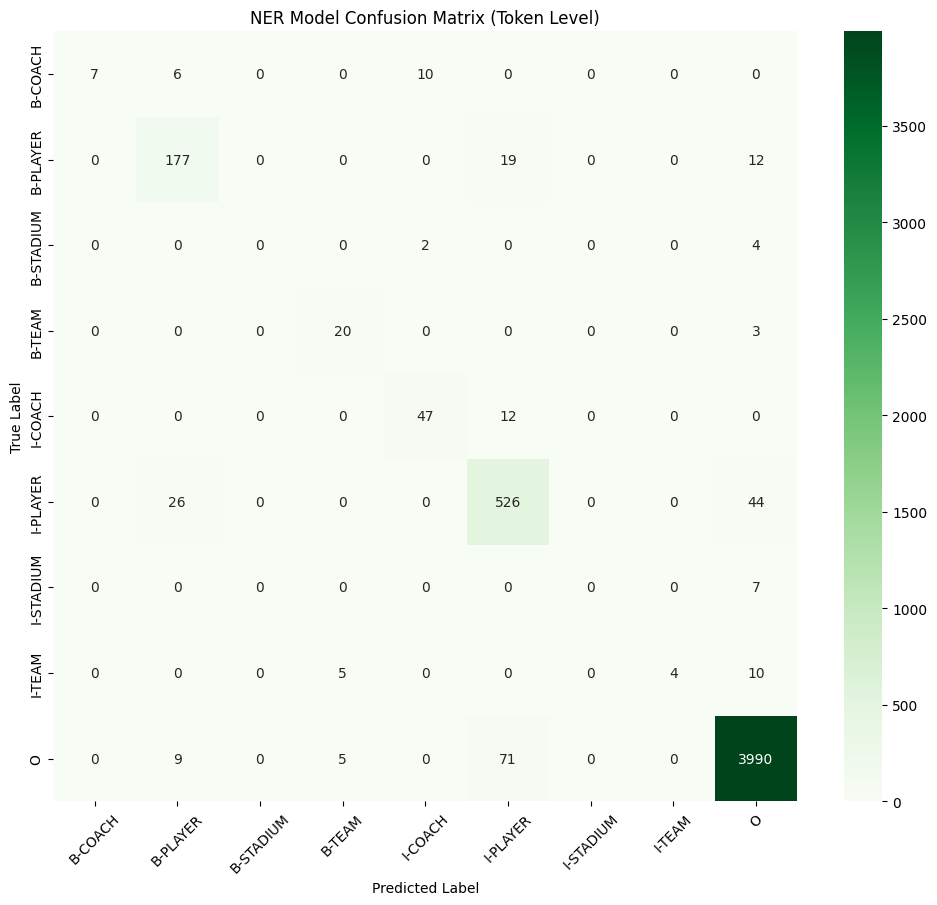

In [6]:
# --- 5. EVALUATION & VISUALIZATION  ---
print("\n📊 Evaluating Model on Test Set...")
predictions = trainer.predict(dataset_split["test"])
preds = np.argmax(predictions.predictions, axis=2)
labels = predictions.label_ids

# Flatten results and remove ignored tokens (-100)
true_labels_flat = []
pred_labels_flat = []

for i in range(len(labels)):
    for j in range(len(labels[i])):
        if labels[i][j] != -100:
            true_labels_flat.append(id2label[labels[i][j]])
            pred_labels_flat.append(id2label[preds[i][j]])

# Classification Report
print("\n📝 Classification Report:")
# Generate report using unique labels present in the data to avoid warnings
unique_tags = sorted(list(set(true_labels_flat + pred_labels_flat)))
print(classification_report(true_labels_flat, pred_labels_flat, labels=unique_tags))

# Confusion Matrix Plot
print("📉 Plotting Confusion Matrix...")
cm = confusion_matrix(true_labels_flat, pred_labels_flat, labels=unique_tags)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=unique_tags, yticklabels=unique_tags)
plt.title('NER Model Confusion Matrix (Token Level)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.show()


### Save the Model

In [7]:
# --- 6. CLEANUP ---
print("💾 Transferring model to global variables...")
ner_model = model
ner_tokenizer = tokenizer

print("🧹 Cleaning RAM...")
del model, trainer, hf_dataset, dataset_split, tokenized_datasets, predictions, preds, labels
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

print("✅ NER MODEL READY. (Stored in 'ner_model')")

💾 Transferring model to global variables...
🧹 Cleaning RAM...
✅ NER MODEL READY. (Stored in 'ner_model')


## Sentiment Model

In [8]:
# ==============================================================================
# SENTIMENT ANALYSIS MODEL TRAINING
# ==============================================================================

import json
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("\n" + "="*40)
print("🚀 3. PREPARING SENTIMENT (EMOTION/EXCITEMENT) MODEL...")
print("="*40)

# --- 1. LOADING THE DATASET ---
data_file = "/content/football_dataset.json" # Check the file name
print(f"📂 Loading dataset: {data_file}")

with open(data_file, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Label List (Order Negative -> Positive is important)
sentiment_labels = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
id2label = {i: label for i, label in enumerate(sentiment_labels)}
label2id = {label: i for i, label in enumerate(sentiment_labels)}

print(f"✅ Sentiment Classes: {sentiment_labels}")

# Parse Data
texts = []
labels = []

for item in raw_data:
    # The dataset might have 'sentiment_label' or 'sentiment' key, check it
    if "sentiment_label" in item and item["sentiment_label"] in label2id:
        texts.append(item["text"])
        labels.append(label2id[item["sentiment_label"]])
    elif "sentiment" in item and item["sentiment"] in label2id:
        texts.append(item["text"])
        labels.append(label2id[item["sentiment"]])

# Convert to Dataset object
hf_dataset = Dataset.from_dict({"text": texts, "label": labels})
dataset_split = hf_dataset.train_test_split(test_size=0.2)

# --- 2. TOKENIZER AND MODEL ---
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

print("⚙️ Tokenizing data...")
tokenized_datasets = dataset_split.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(sentiment_labels),
    id2label=id2label,
    label2id=label2id
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# --- 3. TRAINING ---
training_args = TrainingArguments(
    output_dir="./results_sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",  # Disk saving disabled
    logging_dir='./logs_sentiment',
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)


trainer.train()



🚀 3. PREPARING SENTIMENT (EMOTION/EXCITEMENT) MODEL...
📂 Loading dataset: /content/football_dataset.json
✅ Sentiment Classes: ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
⚙️ Tokenizing data...


Map:   0%|          | 0/1040 [00:00<?, ? examples/s]

Map:   0%|          | 0/260 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.357812
2,No log,0.174126
3,No log,0.124841


TrainOutput(global_step=195, training_loss=0.397325682028746, metrics={'train_runtime': 66.1106, 'train_samples_per_second': 47.194, 'train_steps_per_second': 2.95, 'total_flos': 413305654394880.0, 'train_loss': 0.397325682028746, 'epoch': 3.0})

### Sentiment Model Performance


📊 Evaluating Model...



📝 Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.98      0.98      0.98       143
     NEUTRAL       0.96      0.98      0.97        46
    POSITIVE       0.99      0.97      0.98        71

    accuracy                           0.98       260
   macro avg       0.97      0.98      0.98       260
weighted avg       0.98      0.98      0.98       260



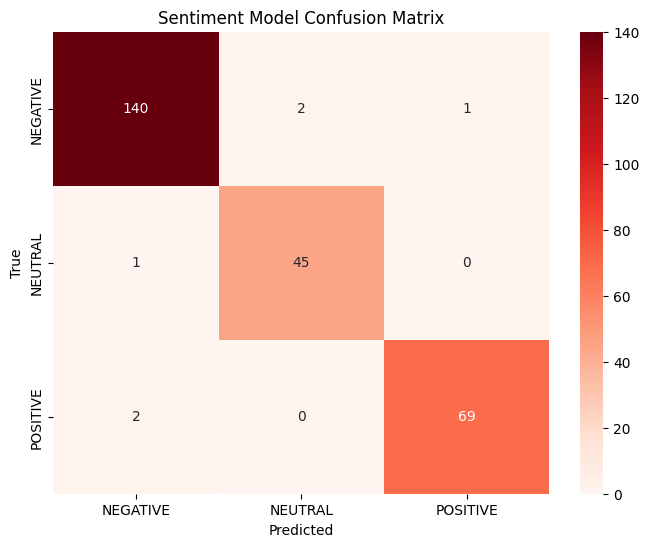

In [9]:
# --- 4. PERFORMANCE ANALYSIS ---
print("\n📊 Evaluating Model...")
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\n📝 Classification Report:")
print(classification_report(true_labels, preds, target_names=sentiment_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('Sentiment Model Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()


### Save the Model

In [10]:
# --- 5. SAVING MODEL TO MEMORY AND CLEANUP (CRITICAL PART) ---
print("💾 Transferring model to global variables...")

# Store Model and Tokenizer
sentiment_model = model
sentiment_tokenizer = tokenizer

print("🧹 Cleaning RAM and GPU...")

# 1. Delete variables
del model
del trainer
del hf_dataset
del dataset_split
del tokenized_datasets
del predictions

# 2. Garbage collector
gc.collect()

# 3. Empty GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ SENTIMENT MODEL READY. (RAM cleaned, model stored in 'sentiment_model' variable)")

💾 Transferring model to global variables...
🧹 Cleaning RAM and GPU...
✅ SENTIMENT MODEL READY. (RAM cleaned, model stored in 'sentiment_model' variable)


## Pipeline

In [11]:
# ==============================================================================
# IMPORTS AND SETUP
# ==============================================================================

import os
import warnings
import whisper
import yt_dlp
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

# Suppress warnings (For clean output)
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Visualization style
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (14, 8)

print("✅ Libraries loaded and settings configured.")

✅ Libraries loaded and settings configured.


In [12]:
# ==============================================================================
# LOADING MODELS INTO PIPELINE
# ==============================================================================

print("📂 Loading models... Please wait.")

# 1. Device Setup (Use GPU if available, else CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"⚙️ Running Device: {device.upper()}")

# 2. Whisper Model (To transcribe audio)
try:
    asr_model = whisper.load_model("large", device=device)
    print("✅ Whisper (ASR) model loaded.")
except Exception as e:
    print(f"❌ Whisper error: {e}")

# 3. Your Trained Models (NER and Event)
try:
    # NER: Detects players/teams
    ner_analyzer = pipeline(
        "token-classification",
        model=ner_model,
        tokenizer=ner_tokenizer,
        aggregation_strategy="simple",
        device=0 if device=="cuda" else -1
    )

    # Event: Detects Goal/Card/Action
    event_analyzer = pipeline(
        "text-classification",
        model=event_model,
        tokenizer=event_tokenizer,
        device=0 if device=="cuda" else -1
    )
    print("✅ Trained models (NER & Event) loaded successfully.")
except Exception as e:
    print(f"❌ Trained models not found! Make sure you ran the training cells above. Error: {e}")

# 4. Sentiment Analysis Model
try:
    sentiment_analyzer = pipeline(
            "text-classification",
            model=sentiment_model,
            tokenizer=sentiment_tokenizer,
            device=0 if device=="cuda" else -1
        )
    print("✅ Sentiment analysis model loaded.")
except Exception as e:
    print(f"❌ Sentiment model not found! Error: {e}")

📂 Loading models... Please wait.
⚙️ Running Device: CUDA


100%|██████████████████████████████████████| 2.88G/2.88G [00:08<00:00, 345MiB/s]
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


✅ Whisper (ASR) model loaded.
✅ Trained models (NER & Event) loaded successfully.
✅ Sentiment analysis model loaded.


In [13]:
# ==============================================================================
# HELPER FUNCTION (VIDEO DOWNLOADER)
# ==============================================================================

def download_video_audio(youtube_url, output_filename="match_audio.mp3"):
    """Downloads YouTube video as an audio file."""

    # Remove existing file if present
    if os.path.exists(output_filename):
        os.remove(output_filename)

    ydl_opts = {
        'format': 'bestaudio/best',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '192',
        }],
        'outtmpl': output_filename.replace('.mp3', ''),
        'quiet': True,
        'no_warnings': True
    }

    print(f"⬇️ Downloading video: {youtube_url}")
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([youtube_url])
        print("✅ Download completed.")
        return output_filename
    except Exception as e:
        print(f"❌ Download error: {e}")
        return None

In [58]:
# ==============================================================================
#  MAIN PIPELINE (UPDATED PREMIER LEAGUE TEAMS 24/25)
# ==============================================================================

from collections import Counter
import pandas as pd
from thefuzz import process # pip install thefuzz

# --- 1. PREMIER LEAGUE 2024/25 STANDARD TEAMS ---
STANDARD_TEAMS = [
    "Arsenal", "Aston Villa", "Bournemouth", "Brentford", "Brighton & Hove Albion",
    "Chelsea", "Crystal Palace", "Everton", "Fulham", "Ipswich Town",
    "Leicester City", "Liverpool", "Manchester United", "Manchester City",
    "Newcastle United", "Nottingham Forest", "Southampton", "Tottenham Hotspur",
    "West Ham United", "Wolverhampton Wanderers"
]

# Manual mapping for nicknames that Fuzzy Matching might miss
NICKNAME_MAP = {
    "spurs": "Tottenham Hotspur",
    "wolves": "Wolverhampton Wanderers",
    "man u": "Manchester United",
    "man utd": "Manchester United",
    "city": "Manchester City",
    "united": "Manchester United", # Context dependent, but usually Man Utd in PL
    "villa": "Aston Villa",
    "palace": "Crystal Palace",
    "forest": "Nottingham Forest",
    "leicester": "Leicester City",
    "ipswich": "Ipswich Town",
    "saints": "Southampton"
}

def standardize_team_name(detected_name, threshold=70):
    """
    1. Checks manual nickname map.
    2. Fuzzy matches against standard DB.
    """
    if not detected_name: return None

    # 1. Check Nicknames first (Exact match check)
    clean_name = detected_name.lower().strip()
    if clean_name in NICKNAME_MAP:
        return NICKNAME_MAP[clean_name]

    # 2. Fuzzy Matching
    match, score = process.extractOne(detected_name, STANDARD_TEAMS)
    if score >= threshold:
        return match

    return detected_name.title()

# --- 2. MAIN FUNCTION ---
def analyze_match_pipeline(youtube_url):
    # A. Download
    audio_path = download_video_audio(youtube_url)
    if not audio_path: return None

    # B. Transcribe
    print("🗣️ Transcribing audio (Whisper)...")
    try:
        result = asr_model.transcribe(audio_path)
        segments = result["segments"]
    except Exception as e:
        print(f"❌ Whisper error: {e}")
        return None

    analysis_data = []
    print(f"🧠 Analyzing {len(segments)} sentences...")

    # C. Settings
    last_goal_time = -999
    last_goal_index = -1
    GOAL_COOLDOWN = 45

    # Balanced Negative Filter
    NEGATIVE_KEYWORDS = [
        "save", "saved", "saves", "miss", "missed", "wide",
        "offside", "flag is up", "disallowed", "VAR check", "side netting"
    ]

    total_segments = len(segments)

    for i in range(total_segments):
        segment = segments[i]
        text = segment["text"]
        start_time = segment["start"]

        # --- PREDICTION ---
        event_pred = event_analyzer(text)[0]
        event_label = event_pred['label']
        event_conf = event_pred['score']

        if event_conf < 0.50: event_label = "NONE"

        # Negative Filter
        if event_label == "GOAL":
            text_lower = text.lower()
            for bad_word in NEGATIVE_KEYWORDS:
                if bad_word in text_lower:
                    event_label = "KEY_CHANCE"
                    print(f"   🛡️ Filtered: '{bad_word}' found. GOAL -> KEY_CHANCE.")
                    break

        # NER
        ner_results = ner_analyzer(text)
        players = [item['word'] for item in ner_results if item['entity_group'] == 'PLAYER']

        primary_player = players[0] if players else None

        # Sentiment
        sent_result = sentiment_analyzer(text)[0]
        sentiment_label = sent_result['label']
        raw_score = sent_result['score']
        sentiment_score = raw_score if sentiment_label == 'POSITIVE' else -raw_score

        # --- LOGIC & MATCHING ---
        primary_team = None

        if event_label == "GOAL":
            if (start_time - last_goal_time) < GOAL_COOLDOWN:
                event_label = "GOAL_COMMENTARY"
                if last_goal_index != -1:
                    if analysis_data[last_goal_index]["Players"] is None and primary_player:
                        analysis_data[last_goal_index]["Players"] = primary_player
            else:
                # NEW GOAL
                print(f"   📊 Analyzing Goal Context at {int(start_time//60)}'...")

                # Window: 1 back, 7 forward
                window_start = max(0, i - 1)
                window_end = min(total_segments, i + 8)

                detected_teams = []
                for j in range(window_start, window_end):
                    scan_text = segments[j]["text"]
                    scan_ner = ner_analyzer(scan_text)
                    raw_teams = [item['word'] for item in scan_ner if item['entity_group'] == 'TEAM']
                    detected_teams.extend(raw_teams)

                if detected_teams:
                    team_counts = Counter(detected_teams)
                    most_common_raw = team_counts.most_common(1)[0][0]

                    # 🔥 APPLY STANDARDIZATION 🔥
                    primary_team = standardize_team_name(most_common_raw)

                    print(f"      👉 Found: '{most_common_raw}' -> Standardized: '{primary_team}'")
                else:
                    print(f"      ❌ No team names mentioned in context.")

                last_goal_time = start_time
                last_goal_index = len(analysis_data)

        # Store
        analysis_data.append({
            "Start": start_time,
            "Minute": int(start_time // 60),
            "Text": text.strip(),
            "Event": event_label,
            "Confidence": event_conf,
            "Players": primary_player,
            "Teams": primary_team,
            "Sentiment_Score": sentiment_score,
            "Sentiment_Label": sentiment_label
        })

    print("✅ Analysis completed.")
    return pd.DataFrame(analysis_data)

In [55]:
# ==============================================================================
# REPORTING FUNCTION (WITH TEAMS FOR SCORERS & CARDS)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def generate_match_report(df):
    print("\n" + "="*70)
    print("📋 DETAILED MATCH REPORT")
    print("="*70 + "\n")

    # --- 1. MATCH SCORE ---
    goals = df[df["Event"] == "GOAL"]
    match_teams = []

    if 'Teams' in df.columns:
        match_teams = df['Teams'].dropna().value_counts().head(2).index.tolist()

    score_str = "Score could not be calculated"

    if len(match_teams) >= 2:
        team_a, team_b = match_teams[0], match_teams[1]
        score_a = 0
        score_b = 0

        for _, row in goals.iterrows():
            scorer_team = row['Teams']
            if scorer_team == team_a:
                score_a += 1
            elif scorer_team == team_b:
                score_b += 1

        score_str = f"{team_a} {score_a} - {score_b} {team_b}"

    elif len(match_teams) == 1:
        score_str = f"{match_teams[0]} (Goals: {len(goals)}) - ???"
    else:
        score_str = f"Total Goals: {len(goals)}"

    print(f"🏆 MATCH RESULT: {score_str}")

    # --- 2. MAN OF THE MATCH ---
    critical_events = ["GOAL", "KEY_CHANCE", "NO_GOAL"]
    key_moments = df[df["Event"].isin(critical_events)]

    top_player = "Undetermined"
    if not key_moments.empty and key_moments['Players'].notnull().any():
        top_player = key_moments['Players'].value_counts().idxmax()
        count = key_moments['Players'].value_counts().max()
        print(f"🌟 MAN OF THE MATCH: {top_player.title()} ({count} critical actions)")
    else:
        print(f"🌟 MAN OF THE MATCH: {top_player}")

    # --- 3. SCORERS (WITH TEAM INFO) ---
    print("\n" + "-"*35)
    print("⚽ GOALSCORERS")

    if not goals.empty:
        # Get unique players who scored
        unique_scorers = goals['Players'].dropna().unique()

        if len(unique_scorers) > 0:
            for player in unique_scorers:
                # Filter rows for this player
                player_goals = goals[goals['Players'] == player]
                count = len(player_goals)

                # Find the associated team (Mode: most frequent team mentioned for this player)
                team_name = ""
                if 'Teams' in player_goals.columns:
                    found_teams = player_goals['Teams'].dropna()
                    if not found_teams.empty:
                        team_name = f"({found_teams.mode()[0]})" # e.g., (Man City)

                print(f" • {player.title()} {team_name} - {count}")
        else:
            print(" • (Players not identified)")
    else:
        print(" • (No goals)")

    # --- 4. BOOKINGS (WITH TEAM INFO) ---
    print("\n" + "-"*35)
    print("🟨🟥 BOOKINGS (CARDS)")

    cards = df[df["Event"] == "CARD"]
    if not cards.empty:
        unique_carded = cards['Players'].dropna().unique()

        if len(unique_carded) > 0:
            for player in unique_carded:
                # Find team for the carded player
                player_cards = cards[cards['Players'] == player]

                team_name = ""
                if 'Teams' in player_cards.columns:
                    found_teams = player_cards['Teams'].dropna()
                    if not found_teams.empty:
                        team_name = f"({found_teams.mode()[0]})"

                print(f" • {player.title()} {team_name}")
        else:
             print(" • (Players not identified)")
    else:
        print(" • (Clean game - No cards detected)")

    # --- 5. CHRONOLOGICAL FEED ---
    print("\n" + "-"*70)
    print("⏱️  CHRONOLOGICAL MATCH FLOW")
    print("-"*70)

    target_events = ["GOAL", "KEY_CHANCE", "CARD"]
    timeline_df = df[df["Event"].isin(target_events)].sort_values("Start")

    if timeline_df.empty:
        print("   (No significant event detected.)")
    else:
        for _, row in timeline_df.iterrows():
            min_str = str(row['Minute']).zfill(2)
            evt = row['Event']
            txt = row['Text'][:80] + "..." if len(row['Text']) > 80 else row['Text']

            print(f"[{min_str}'] {evt.ljust(12)} | \"{txt}\"")

    # --- 6. SENTIMENT GRAPH ---
    print("\n📈 Creating Sentiment Analysis Graph...")

    sns.set_style("whitegrid")
    plt.figure(figsize=(15, 6))

    y_values = []
    colors = []
    sizes = []

    for _, row in df.iterrows():
        if row['Event'] == 'GOAL':
            y_values.append(1.0)
            colors.append('#FF0000') # Red
            sizes.append(150)
        else:
            label = row.get('Sentiment_Label', 'NEUTRAL')
            if label == 'POSITIVE': y_values.append(0.7)
            elif label == 'NEUTRAL': y_values.append(0.5)
            else: y_values.append(0.2)

            colors.append('#DAA520') # Goldenrod
            sizes.append(50)

    x_values = range(len(df))

    plt.plot(x_values, y_values, color='#DAA520', linestyle='-', linewidth=1.5, alpha=0.6, label='Sentiment Flow')
    plt.scatter(x_values, y_values, c=colors, s=sizes, alpha=1.0, edgecolors='black', linewidth=0.5, zorder=10)

    plt.ylim(0, 1.2)
    plt.yticks([0.2, 0.5, 0.7, 1.0], ["Negative", "Neutral", "Positive", "GOAL"], fontsize=10, fontweight='bold')
    plt.xlabel("Commentary Sequence", fontsize=12)
    plt.title(f"Match Sentiment Analysis: {score_str}", fontsize=15, pad=20)

    plt.tight_layout()
    plt.show()

In [44]:
# ==============================================================================
# EXECUTION FUNCTION (RUN EVERYTHING)
# ==============================================================================

def run_full_analysis(youtube_link):
    """
    Runs the full match analysis pipeline:
    1. Downloads audio
    2. Transcribes & Analyzes (Event, NER, Sentiment)
    3. Saves data to CSV
    4. Generates the Visual Report
    """

    print(f"\n🎬 Analysis Starting: {youtube_link}")

    # 1. Run the Main Pipeline (Cell 7 Function)
    try:
        df_result = analyze_match_pipeline(youtube_link)
    except NameError:
        print("❌ ERROR: 'analyze_match_pipeline' not defined. Please run Cell 7.")
        return

    # 2. Process Results
    if df_result is not None:
        # Save Backup
        filename = "final_match_analyzed.csv"
        df_result.to_csv(filename, index=False)
        print(f"💾 Raw data saved as '{filename}'.\n")

        # 3. Generate Report (Cell 8 Function)
        try:
            generate_match_report(df_result)
        except NameError:
            print("❌ ERROR: 'generate_match_report' not defined. Please run Cell 8.")
            print("   Make sure you have executed the Reporting Function cell.")
    else:
        print("❌ Analysis failed. No data was returned from the pipeline.")



🎬 Analysis Starting: https://www.youtube.com/watch?v=jzsDwqVEFRQ&t=8s
⬇️ Downloading video: https://www.youtube.com/watch?v=jzsDwqVEFRQ&t=8s
✅ Download completed.
🗣️ Transcribing audio (Whisper)...
🧠 Analyzing 234 sentences...
   📊 Analyzing Goal Context at 0'...
      👉 Found: 'city' -> Standardized: 'Manchester City'
   📊 Analyzing Goal Context at 1'...
      ❌ No team names mentioned in context.
   📊 Analyzing Goal Context at 3'...
      ❌ No team names mentioned in context.
   📊 Analyzing Goal Context at 4'...
      👉 Found: 'city' -> Standardized: 'Manchester City'
   📊 Analyzing Goal Context at 6'...
      👉 Found: 'liverpool' -> Standardized: 'Liverpool'
   📊 Analyzing Goal Context at 7'...
      👉 Found: 'city' -> Standardized: 'Manchester City'
✅ Analysis completed.
💾 Raw data saved as 'final_match_analyzed.csv'.


📋 DETAILED MATCH REPORT

🏆 MATCH RESULT: Manchester City 3 - 1 Liverpool
🌟 MAN OF THE MATCH: Mo Salah (1 critical actions)

-----------------------------------
⚽ G

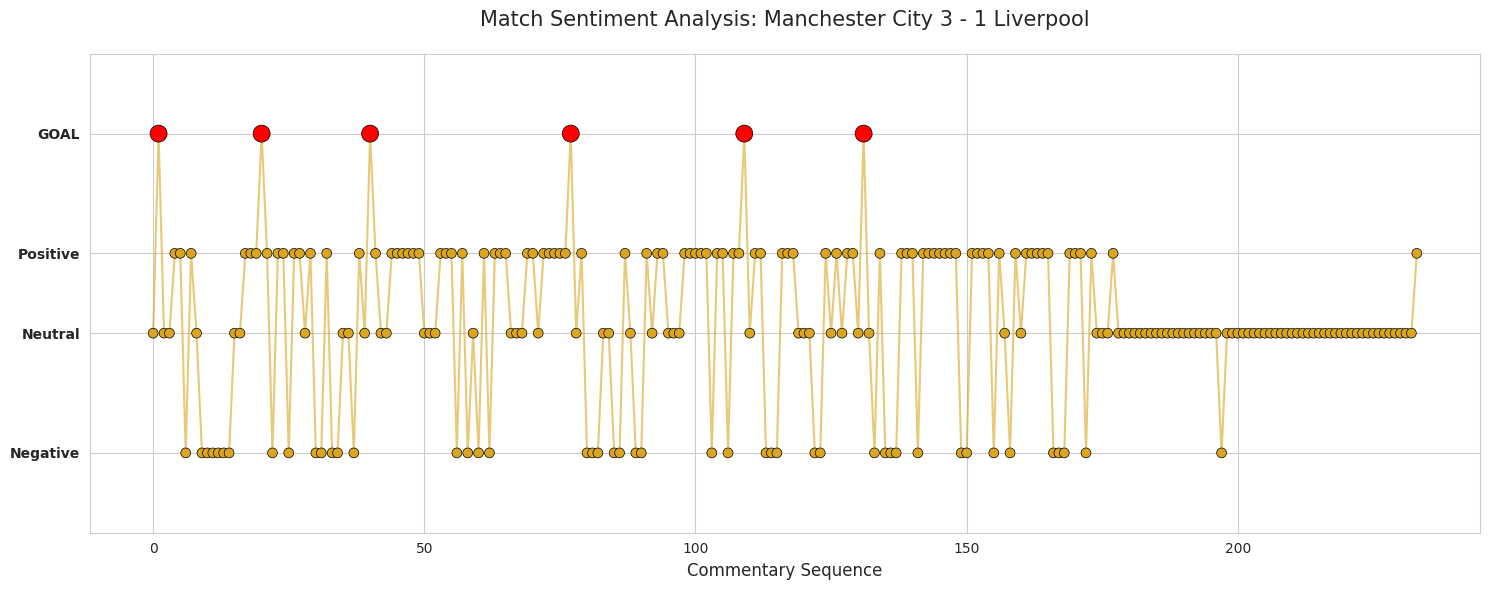

In [59]:
# ==============================================================================
# 🏁 HOW TO USE:
# ==============================================================================


# Just change the link below and run this cell.
VIDEO_URL = "https://www.youtube.com/watch?v=jzsDwqVEFRQ&t=8s"

run_full_analysis(VIDEO_URL)